In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

### Zadanie 4. Ścieżki ewolucji gwiazd

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93 entries, 0 to 92
Data columns (total 20 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   age/yr   93 non-null     float64
 1   logL     93 non-null     float64
 2   logTef   93 non-null     float64
 3   grav     93 non-null     float64
 4   logTc    93 non-null     float64
 5   logrho   93 non-null     float64
 6   Xc,Yc    93 non-null     float64
 7   Xc_C     93 non-null     float64
 8   Xc_O     93 non-null     float64
 9   Q_conv   93 non-null     float64
 10  Q_disc   93 non-null     float64
 11  logL_H   93 non-null     float64
 12  Q1_H     93 non-null     float64
 13  Q2_H     93 non-null     float64
 14  logL_He  93 non-null     float64
 15  Q1_He    93 non-null     float64
 16  Q2_He    93 non-null     float64
 17  logL_C   93 non-null     float64
 18  logL_nu  93 non-null     float64
 19  Q_Tmax   93 non-null     float64
dtypes: float64(20)
memory usage: 14.7 KB
<class 'pandas.core

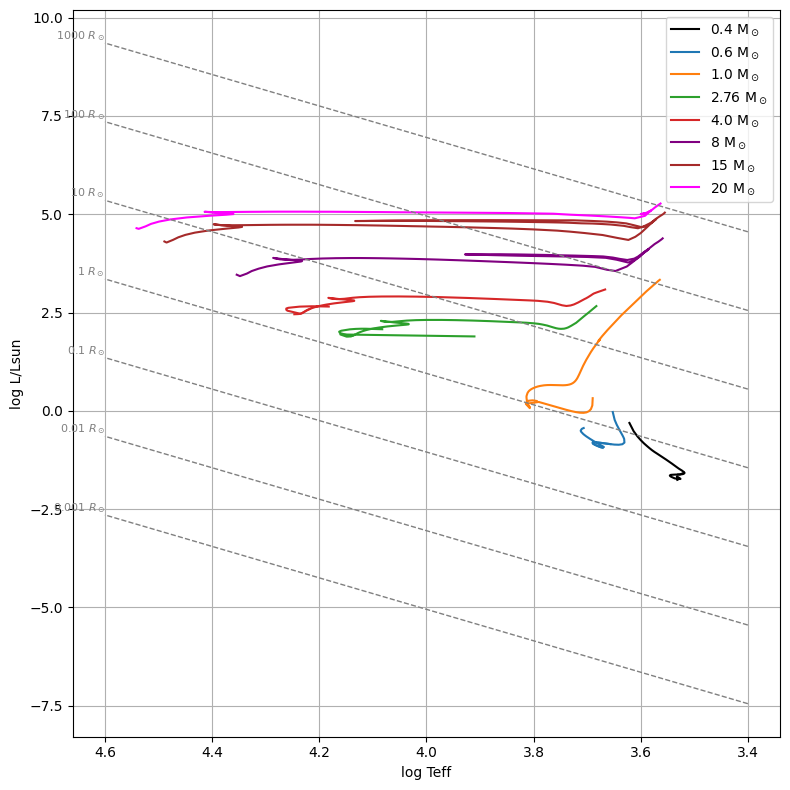

In [4]:
fig, ax = plt.subplots(figsize=(8, 8), tight_layout=True)

file_names = ["_04", "_06", "_10", "_27", "_40"]
colors = ["#000000", "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]  # black, blue, orange, green, red
labels = [r"0.4 $\rm M_\odot$", r"0.6 $ \rm M_\odot$", r"1.0 $\rm M_\odot$", r"2.76 $\rm M_\odot$", r"4.0 $\rm M_\odot$"]

path_to_files = r"/media/olehryz/Elements/progs/univ_codes/2025_2026/semester_02/inner_stars/tracks"

for name in file_names:
    
    name1 = f"o.track1{name}"
    file1 = os.path.join(path_to_files, name1)

    data1 = pd.read_csv(file1, delim_whitespace=True, skiprows=1,
                       names=["N", "Age(Gyr)", "log_Teff", "log_L_Lsun", "Ycore", "Mcore"])
    # Plot log Teff (x, reversed) vs log L/Lsun (y)
    ax.plot(data1["log_Teff"], data1["log_L_Lsun"], color=colors[file_names.index(name)])


    name2 = f"o.track2{name}"
    file2 = os.path.join(path_to_files, name2)

    data2 = pd.read_csv(file2, delim_whitespace=True, skiprows=1,
                       names=["N", "Age(Gyr)", "log_Teff", "log_L_Lsun", "Ycore", "Mcore"])
    # Plot log Teff (x, reversed) vs log L/Lsun (y)
    ax.plot(data2["log_Teff"], data2["log_L_Lsun"], label=labels[file_names.index(name)], color=colors[file_names.index(name)])

ms_files = [
    ("ms0800z019s.dat", "8 $\\rm M_\\odot$", "purple"),
    ("ms1500z019s.dat", "15 $\\rm M_\\odot$", "brown"),
    ("ms2000z019s.dat", "20 $\\rm M_\\odot$", "magenta"),
]

for fname, label, color in ms_files:
    ms_path = os.path.join(path_to_files, fname)
    # Skip header row, use whitespace delimiter, and extract logTef and logL columns
    ms_data = pd.read_csv(ms_path, delim_whitespace=True, comment="#", engine="python")
    ax.plot(ms_data["logTef"], ms_data["logL"], label=label, color=color)
    ms_data.info()

# Linie stałego promienia
R_sun = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
log_Teff_range = np.linspace(3.4, 4.6, 200)  # zakres typowy dla HR diagramu
T_sun = 5777
log_T_sun = np.log10(T_sun)

for R in R_sun:
    logL = 2 * np.log10(R) + 4 * log_Teff_range - 4 * log_T_sun
    ax.plot(log_Teff_range, logL, '--', color='gray', lw=1)
    # podpisz linię tylko raz, np. przy log_Teff=4.15
    idx = -1  # koniec zakresu
    ax.text(log_Teff_range[idx], logL[idx], f"{R} $R_\\odot$", color='gray', fontsize=8, va='bottom', ha='right', rotation=0)

ax.invert_xaxis()  # HR diagram: Teff decreases to the right
ax.set_xlabel("log Teff")
ax.set_ylabel("log L/Lsun")
ax.grid()
ax.legend()
plt.show()